<a href="https://colab.research.google.com/github/wyattae/cosc-650-applied-llm-systems/blob/WE_4/src/week2/week2_inference_sampling_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'The best programming language is'   # TODO (you): your own short prompt
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 1266, 8300, 3303, 318]
  pos 0: id    464 -> 'The'
  pos 1: id   1266 -> ' best'
  pos 2: id   8300 -> ' programming'
  pos 3: id   3303 -> ' language'
  pos 4: id    318 -> ' is'

embedded prompt shape (seq_len, dim): (5, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.480
  ' best'      0.196
  ' programming' 0.152
  ' language'  0.110
  ' is'        0.062

logits shape (batch, seq, vocab): (1, 5, 50257)
top 10 next tokens:
  ' the'         0.0871
  ' written'     0.0336
  ' a'           0.0324
  ' Python'      0.0287
  ' JavaScript'  0.0237
  ' Java'        0.0211
  ','            0.0193
  ' not'         0.0188
  ' available'   0.0161
  ' built'       0.0144


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

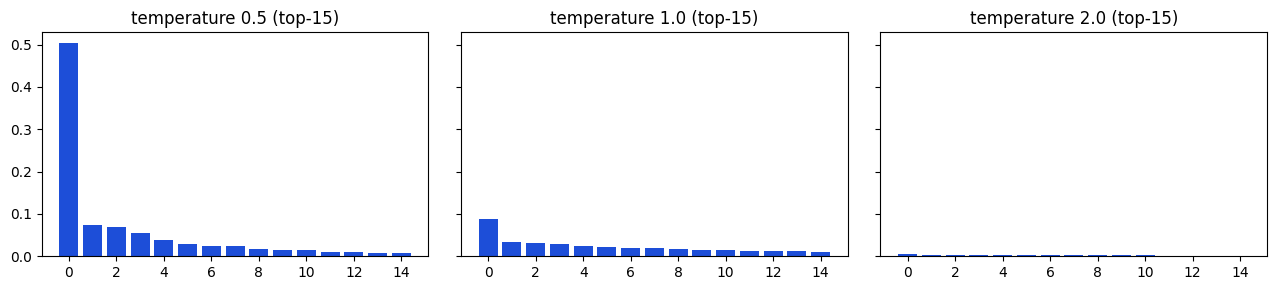

top token prob: temp 0.5 = 0.504, temp 1.0 = 0.087, temp 2.0 = 0.005


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp, k in [(1e-6, 1.0, None), (0.7, 1.0, 100), (1.3, 0.9, 1000)]:
    p = temperature(z, t)
    if k is not None:
      p = top_k(p,k)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp} top-k {k}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
# TODO (you): for each row, write what you predicted versus what you see.
# PREDICTION 1 #
# Temp = 1e-6, top-p = 1.0, top-k = None
# I am expecting to see a very deterministic answer with a temp of 1e-6. Having a top-p of 1.0 would make you think that there will be a larger kept list
# to reach the threshold, but dividing by 1e-6 could case the top selection to pull ahead enough to warrant 1 return value.
#
# entropy: extremely low near zero.
# max prob: extremely high near 1.
# kept: 1... maybe 2 O_o
#
# ACTUAL 1 #
#
# entropy: -0.000
# max prob: 1.000
# kept: 1
#
# PREDICTION 2 #
# Temp = 0.7, top-p = 1.0, top-k = 100
# With a temp of 0.7 the probability curve will definitely be flatter, and I am expected the top-k to max out, since top-p is remaining at 1.0
#
# entropy: higher entropy than in test 1. Potentially around .5.
# max prob: This will be great reduced from test 1. I would say .3
# kept: 100. I am predicting top-k will be reached here since top-p is 1.
#
# ACTUAL 2 #
#
# entropy: 3.258
# max prob: .278
# kept: 100
#
# PREDICTION 3 #
# Temp = 1.3, top-p = 0.9, top-k = 1000
# This will follow a similar trend to test 2, but more exaggerated. More flattened probabiliy distribution, top-k maxed out with 1000 kept.
#
# entropy: less than .1
# max prob: less than .1.. lets say .05
# kept: 1000
#
# ACTUAL 3 #
#
# entropy: 6.002
# max prob: .045
# kept: 603
#
#Reflection:
# Test 1:
# I predicted these values correct, although I was unsure how the total kept would shake out in my prediction. I thought there would be a
# chance of getting 2 returns. Turns out that having temperature so low still creates an extremely deterministic result.
#
# Test 2:
# I predicted max prob and kept really well. Although my unfamiliarity with the entropy function is starting to show. I did predict entropy would go
# up but, was not sure if it would return in the 0-1 range. So this will also show in my test 3 prediction as well.
#
# Test 3:
# My entropy prediction was bad, I think I got a little distracted, I put .1 but my intent was that it would increase. I am surprised my max probabily was so close.
# this was just a good guess. I thought kept would max out at 1000, but turns out 603 were kept. I would imagine if temperature is increased to 2, we would see that happen.


temp 1e-06  top-p 1.0 top-k None: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0 top-k 100: entropy 3.258, max prob 0.278, nucleus keeps 100 tokens
temp 1.3    top-p 0.9 top-k 1000: entropy 6.002, max prob 0.045, nucleus keeps 603 tokens


## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [5]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)')
# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.

for t, tp, k in [(2, 1, None), (1, 1.0, None), (.106, 1.0, None)]:
    p = temperature(z, t)
    if k is not None:
      p = top_k(p,k)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')

# I tested variable tempature values with top-p remaining constant at 1.0. My findings showed how important it is to have logic that trims the probability distribution tail.
# From my tests you can see that with a top_p of 1, you will be keeping all tokens in the vocab until temperature reduces below .107. As a newcomer to LLM systems myself,
# this surpsied me that the collapse happened so suddenly once temperature hit .106 and only 10 tokens were returned. This is likely because the floating point precision
# became so small that the probabily of the thousands of excess tokens became nearly zero. My conclusion is that top-p and top-k are essential configurations even at low temperature
# values, to minimize the probabiliy distribution tail and remove tokens that should never be under consideration.

temp -> 0: top token prob = 1.0 (greedy collapse)
temp 2      top-p 1: entropy 9.579, max prob 0.005, nucleus keeps 50258 tokens
temp 1      top-p 1.0: entropy 6.026, max prob 0.087, nucleus keeps 50258 tokens
temp 0.106  top-p 1.0: entropy 0.003, max prob 1.000, nucleus keeps 10 tokens


## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).